In [1]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Create project directory structure
import os
project_path = '/content/drive/MyDrive/10_Academy_Week9'
os.makedirs(project_path, exist_ok=True)
os.makedirs(f'{project_path}/data', exist_ok=True)
os.makedirs(f'{project_path}/notebooks', exist_ok=True)
os.makedirs(f'{project_path}/results', exist_ok=True)
os.makedirs(f'{project_path}/results/plots', exist_ok=True)

# Install required packages
!pip install -q yfinance pandas numpy matplotlib seaborn scipy statsmodels pmdarima scikit-learn tensorflow PyPortfolioOpt

# Navigate to project directory
%cd {project_path}

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 15.5 MB/s eta 0:00:00
/content/drive/MyDrive/10_Academy_Week9


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Statistical and ML libraries
from scipy import stats
from scipy.stats import jarque_bera, normaltest
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Portfolio Optimization
from pypfopt import expected_returns, risk_models, EfficientFrontier
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Define tickers and date range
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

# Download adjusted close prices
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
data.dropna(inplace=True)

# Display info
print(f"Data shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")

# Save to CSV (optional but good practice)
data.to_csv(f'{project_path}/data/asset_prices.csv')

# Calculate daily returns
returns = data.pct_change().dropna()
returns.to_csv(f'{project_path}/data/asset_returns.csv')

[*********************100%***********************]  3 of 3 completed


Data shape: (2888, 3)
Columns: ['BND', 'SPY', 'TSLA']
Date range: 2015-01-02 to 2026-06-29


In [5]:
# Quick data quality report
print("\n--- Data Quality Report ---")
print(f"Missing values:\n{data.isnull().sum()}")
print(f"Duplicate index: {data.index.duplicated().sum()}")
print(f"Zero or negative values:\n{(data <= 0).sum()}")

# Basic statistics
print("\n--- Summary Statistics ---")
print(data.describe())


--- Data Quality Report ---
Missing values:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64
Duplicate index: 0
Zero or negative values:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

--- Summary Statistics ---
Ticker          BND          SPY         TSLA
count   2888.000000  2888.000000  2888.000000
mean      66.503052   351.505531   148.773923
std        4.713607   155.443935   138.895957
min       58.729248   154.161606     9.578000
25%       62.478089   223.546814    18.393499
50%       65.728405   312.817902   133.437668
75%       70.689144   432.806793   251.925831
max       74.832863   757.618225   489.880005


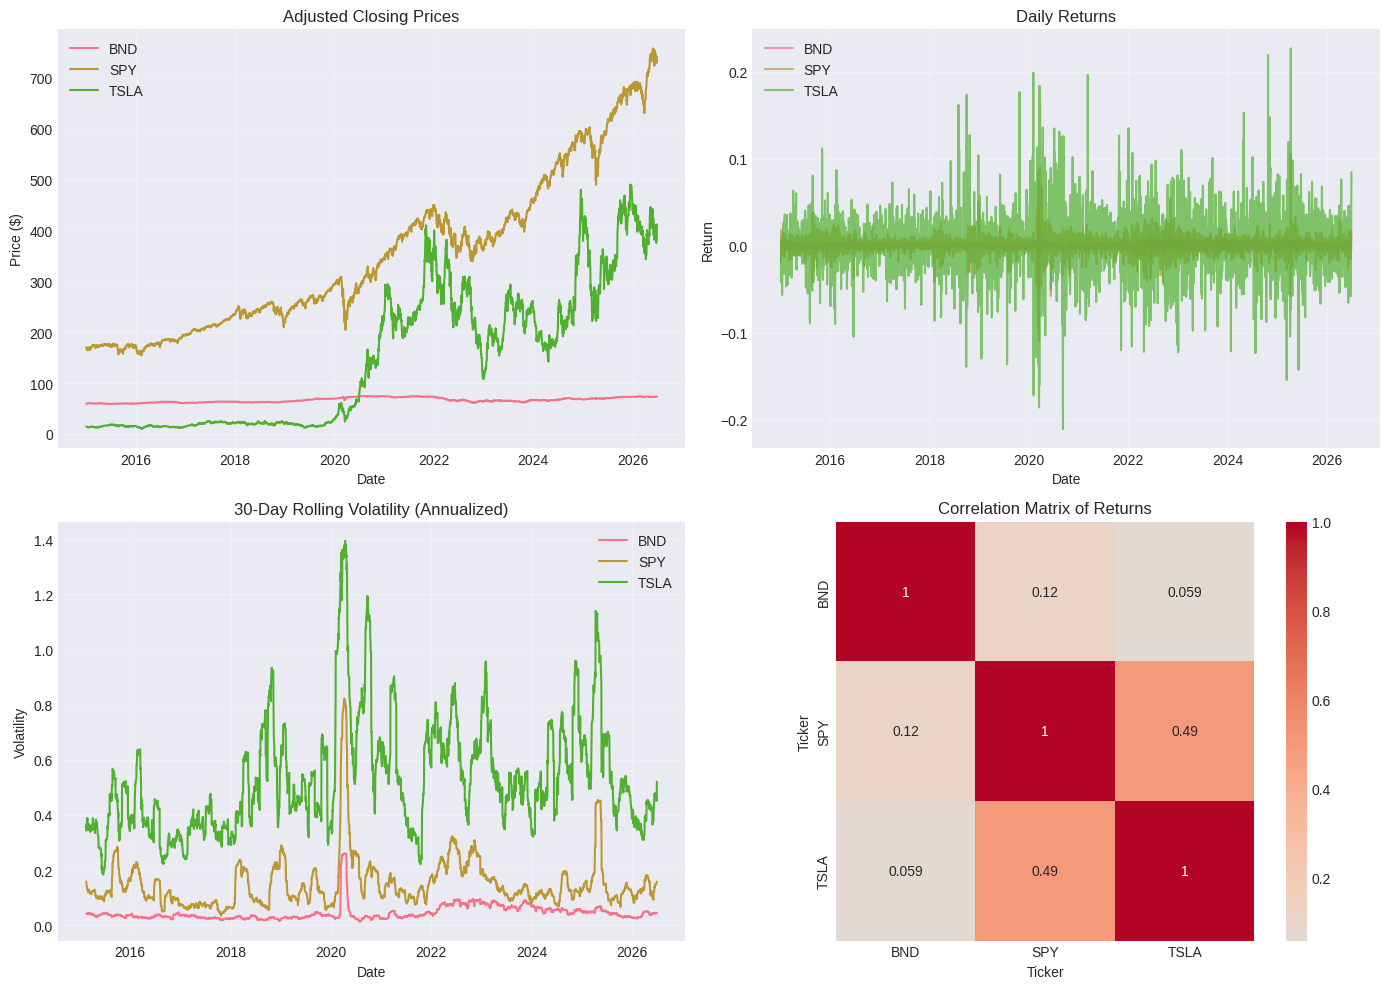

✅ EDA plots saved to results/plots/eda_visualizations.png


In [6]:
# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Closing prices
for ticker in data.columns:
    axes[0,0].plot(data.index, data[ticker], label=ticker)
axes[0,0].set_title('Adjusted Closing Prices')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Price ($)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Daily returns
for ticker in returns.columns:
    axes[0,1].plot(returns.index, returns[ticker], label=ticker, alpha=0.7)
axes[0,1].set_title('Daily Returns')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Return')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Rolling volatility (30-day window, annualized)
rolling_vol = returns.rolling(30).std() * np.sqrt(252)
for ticker in rolling_vol.columns:
    axes[1,0].plot(rolling_vol.index, rolling_vol[ticker], label=ticker)
axes[1,0].set_title('30-Day Rolling Volatility (Annualized)')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Volatility')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Correlation heatmap
corr = returns.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix of Returns')

plt.tight_layout()
plt.savefig(f'{project_path}/results/plots/eda_visualizations.png', dpi=300)
plt.show()
print("✅ EDA plots saved to results/plots/eda_visualizations.png")

In [7]:
def check_stationarity(series, series_name):
    result = adfuller(series, autolag='AIC')
    print(f"\n--- ADF Test: {series_name} ---")
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print("Critical values:")
    for key, val in result[4].items():
        print(f"  {key}: {val:.6f}")
    if result[1] <= 0.05:
        print("✅ Stationary (reject H0)")
    else:
        print("❌ Non-stationary (fail to reject H0)")

# Test prices and returns
for ticker in data.columns:
    check_stationarity(data[ticker], f"{ticker} Price")
for ticker in returns.columns:
    check_stationarity(returns[ticker], f"{ticker} Returns")


--- ADF Test: BND Price ---
ADF Statistic: -1.082707
p-value: 0.721919
Critical values:
  1%: -3.432627
  5%: -2.862546
  10%: -2.567306
❌ Non-stationary (fail to reject H0)

--- ADF Test: SPY Price ---
ADF Statistic: 1.308944
p-value: 0.996659
Critical values:
  1%: -3.432624
  5%: -2.862545
  10%: -2.567305
❌ Non-stationary (fail to reject H0)

--- ADF Test: TSLA Price ---
ADF Statistic: -1.069599
p-value: 0.727042
Critical values:
  1%: -3.432639
  5%: -2.862551
  10%: -2.567308
❌ Non-stationary (fail to reject H0)

--- ADF Test: BND Returns ---
ADF Statistic: -15.216119
p-value: 0.000000
Critical values:
  1%: -3.432627
  5%: -2.862546
  10%: -2.567306
✅ Stationary (reject H0)

--- ADF Test: SPY Returns ---
ADF Statistic: -17.572185
p-value: 0.000000
Critical values:
  1%: -3.432624
  5%: -2.862545
  10%: -2.567305
✅ Stationary (reject H0)

--- ADF Test: TSLA Returns ---
ADF Statistic: -53.971893
p-value: 0.000000
Critical values:
  1%: -3.432618
  5%: -2.862542
  10%: -2.567303
✅


--- Risk Metrics ---
      VaR (95%)  CVaR (95%)  Sharpe Ratio  Max Drawdown  Annual Volatility
BND     -0.0048     -0.0074       -0.0008       -0.1858             0.0531
SPY     -0.0167     -0.0268        0.7042       -0.3372             0.1765
TSLA    -0.0517     -0.0786        0.7595       -0.7363             0.5718


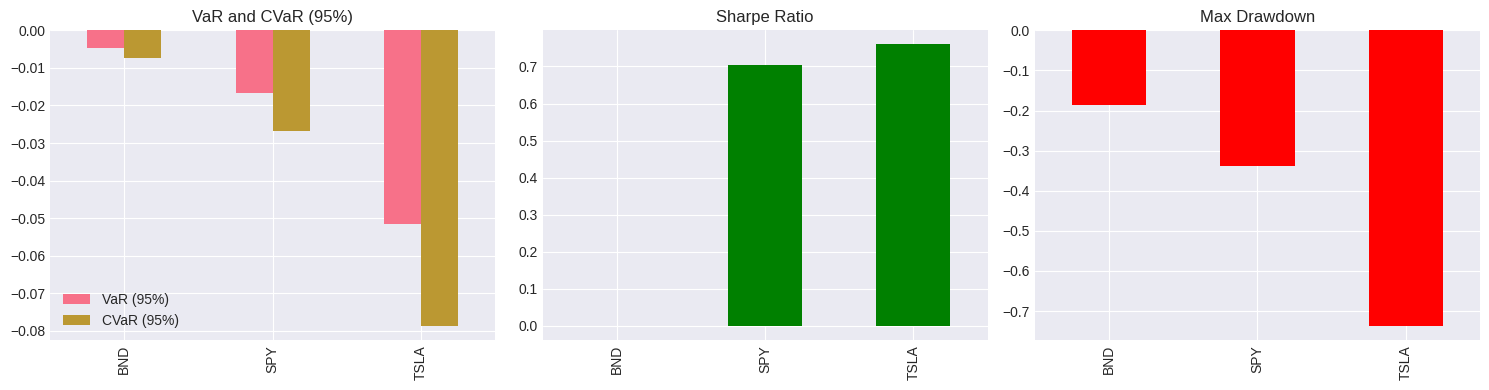

✅ Risk metrics plot saved.


In [8]:
# Calculate and display risk metrics for each asset
risk_metrics = {}

for ticker in returns.columns:
    r = returns[ticker]
    # VaR
    var_95 = r.quantile(0.05)
    cvar_95 = r[r <= var_95].mean()
    # Sharpe (annualized, risk-free = 2%)
    rf = 0.02
    sharpe = np.sqrt(252) * (r.mean() - rf/252) / r.std()
    # Max drawdown
    cum = (1 + r).cumprod()
    dd = (cum / cum.cummax()) - 1
    max_dd = dd.min()
    # Volatility
    vol = r.std() * np.sqrt(252)

    risk_metrics[ticker] = {
        'VaR (95%)': var_95,
        'CVaR (95%)': cvar_95,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Annual Volatility': vol
    }

# Create DataFrame and display
risk_df = pd.DataFrame(risk_metrics).T
print("\n--- Risk Metrics ---")
print(risk_df.round(4))

# Save table
risk_df.to_csv(f'{project_path}/results/risk_metrics.csv')

# Visualize key risk metrics
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
risk_df[['VaR (95%)', 'CVaR (95%)']].plot(kind='bar', ax=axs[0])
axs[0].set_title('VaR and CVaR (95%)')
risk_df['Sharpe Ratio'].plot(kind='bar', ax=axs[1], color='green')
axs[1].set_title('Sharpe Ratio')
risk_df['Max Drawdown'].plot(kind='bar', ax=axs[2], color='red')
axs[2].set_title('Max Drawdown')

plt.tight_layout()
plt.savefig(f'{project_path}/results/plots/risk_metrics.png', dpi=300)
plt.show()
print("✅ Risk metrics plot saved.")

Train size: 2516, Test size: 372

Searching best ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=1.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=1.10 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.679 seconds

✅ Best order: (0, 1, 0)

--- ARIMA Performance ---
MAE:  $54.44
RMSE: $70.54
MAPE: nan%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


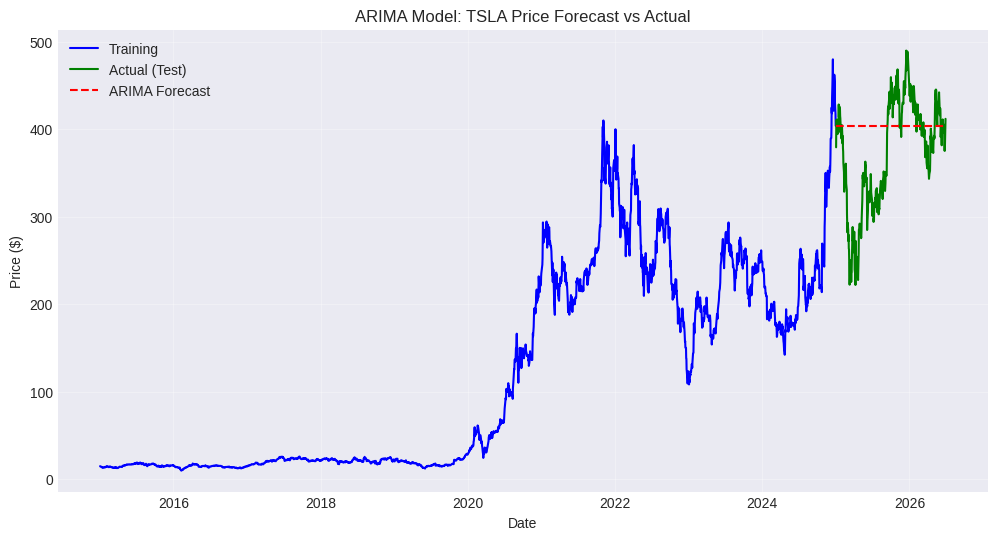

✅ ARIMA forecast plot saved.


In [9]:
# Split data chronologically
tsla = data['TSLA']
train = tsla[:'2024-12-31']
test = tsla['2025-01-01':]

print(f"Train size: {len(train)}, Test size: {len(test)}")

# Auto ARIMA
print("\nSearching best ARIMA parameters...")
arima_model = auto_arima(train, start_p=0, max_p=5, d=1, start_q=0, max_q=5,
                         seasonal=False, trace=True, error_action='ignore',
                         suppress_warnings=True, stepwise=True, n_fits=50)

print(f"\n✅ Best order: {arima_model.order}")

# Forecast on test set
forecast = arima_model.predict(n_periods=len(test))
forecast_index = test.index

# Create DataFrame with actual vs predicted
results_arima = pd.DataFrame({
    'Actual': test,
    'Predicted': forecast
}, index=forecast_index)

# Calculate metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"\n--- ARIMA Performance ---")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plot predictions
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training', color='blue')
plt.plot(test.index, test, label='Actual (Test)', color='green')
plt.plot(test.index, forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Model: TSLA Price Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{project_path}/results/plots/arima_forecast.png', dpi=300)
plt.show()
print("✅ ARIMA forecast plot saved.")